# Car Sales — Interpretability & Fairness
**Team LGTSOW**
**Notebook 5 — Interpretability & Fairness**
**File:** `P1_CarSales-5_xAI_LGTSOW.ipynb`

> **Portability:** Same ACES `sys.path` fix and portable `DATA_DIR` resolver as
> Notebooks 3-4.

This notebook interprets the best tree-based model from Notebook 4 (the Random
Forest trained on the selected feature set) with SHAP, then audits it for subgroup
performance disparities using Fairlearn.

In [1]:
import sys, os

pkg_dir = os.path.expandvars('$SCRATCH/python_packages')
if os.path.isdir(pkg_dir) and pkg_dir not in sys.path:
    sys.path.insert(0, pkg_dir)
    print(f"Added to sys.path: {pkg_dir}")

Added to sys.path: /scratch/user/u.gd352312/python_packages


In [2]:
import glob
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from fairlearn.metrics import MetricFrame

np.random.seed(42)

## 1. Data Read

Same portable data-directory resolution as Notebooks 3-4, but pointed at
`selected_test.csv` (Notebook 4's output) rather than `processed_test.csv` --
Notebook 4's feature-selected data is what the model we're loading was actually
trained on.

In [3]:
CANDIDATE_DATA_DIRS = [
    os.environ.get('CARSALES_DATA_DIR'),
    '.',
    os.path.expanduser('~/scratch/msds565'),
    os.path.expanduser('~/msds565/data'),
]

DATA_DIR = None
for candidate in CANDIDATE_DATA_DIRS:
    if candidate and os.path.exists(os.path.join(candidate, 'selected_test.csv')):
        DATA_DIR = candidate
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find selected_test.csv in any candidate data directory: "
        f"{[c for c in CANDIDATE_DATA_DIRS if c]}\n"
        "Set the CARSALES_DATA_DIR environment variable to your class data folder."
    )

print(f"Using data directory: {os.path.abspath(DATA_DIR)}")

Using data directory: /scratch/user/u.gd352312/Car_Sales


In [4]:
test_df = pd.read_csv(os.path.join(DATA_DIR, 'selected_test.csv'))
print(f"selected_test.csv: {test_df.shape[0]:,} rows x {test_df.shape[1]} columns")

# Same dtype-based detection Notebooks 3-4 used -- robust regardless of the exact
# meta_ prefix naming, and correctly excludes price from the metadata list.
metadata_cols = test_df.select_dtypes(include='object').columns.tolist()
print(f"Metadata columns (subgroup dimensions for the fairness audit): {metadata_cols}")

y_test = test_df['price']
X_test = test_df.drop(columns=['price'] + metadata_cols)
print(f"X_test: {X_test.shape}")

selected_test.csv: 60,462 rows x 106 columns
Metadata columns (subgroup dimensions for the fairness audit): ['meta_city', 'meta_bed', 'meta_body_type', 'meta_cabin', 'meta_exterior_color', 'meta_franchise_make', 'meta_fuel_type', 'meta_interior_color', 'listed_date', 'meta_listing_color', 'meta_make_name', 'meta_model_name', 'meta_transmission', 'meta_trim_name', 'meta_wheel_system', 'meta_engine_layout']
X_test: (60462, 89)


**Loading the saved Random Forest.** Notebook 4 exported it as
`P1_N<fold>_rf_selected.pkl`, where `<fold>` is whichever CV fold scored best for
that specific model -- not a fixed number we can hardcode. We find it by pattern
match instead of guessing the filename.

In [5]:
MODELS_DIR = 'models'

rf_candidates = glob.glob(os.path.join(MODELS_DIR, 'P1_N*_rf_selected.pkl'))
if len(rf_candidates) != 1:
    raise FileNotFoundError(
        f"Expected exactly one P1_N*_rf_selected.pkl in {MODELS_DIR}/, found {len(rf_candidates)}: "
        f"{rf_candidates}. Make sure Notebook 4 has been run and exported its model."
    )

rf_model_path = rf_candidates[0]
with open(rf_model_path, 'rb') as f:
    rf_model = pickle.load(f)

print(f"Loaded: {rf_model_path}")

Loaded: models/P1_N3_rf_selected.pkl


## 2. SHAP

**Sampling.** SHAP values are computed per-row and get expensive at scale, so we work
on a random sample rather than the full test set -- 300 rows is enough for a stable
beeswarm summary while staying fast. `random_state=42` keeps this reproducible.

In [6]:
SHAP_SAMPLE_SIZE = 300
X_shap_sample = X_test.sample(n=min(SHAP_SAMPLE_SIZE, len(X_test)), random_state=42)

print(f"SHAP sample: {X_shap_sample.shape[0]} rows x {X_shap_sample.shape[1]} features")

SHAP sample: 300 rows x 89 features


**Computing SHAP values.** `TreeExplainer` is the fast, exact SHAP algorithm
built specifically for tree ensembles like Random Forest -- no approximation needed,
unlike the model-agnostic explainers required for e.g. the Keras network.

In [7]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_shap_sample)

print(f"SHAP values shape: {shap_values.values.shape}")

SHAP values shape: (300, 89)


### Beeswarm plot

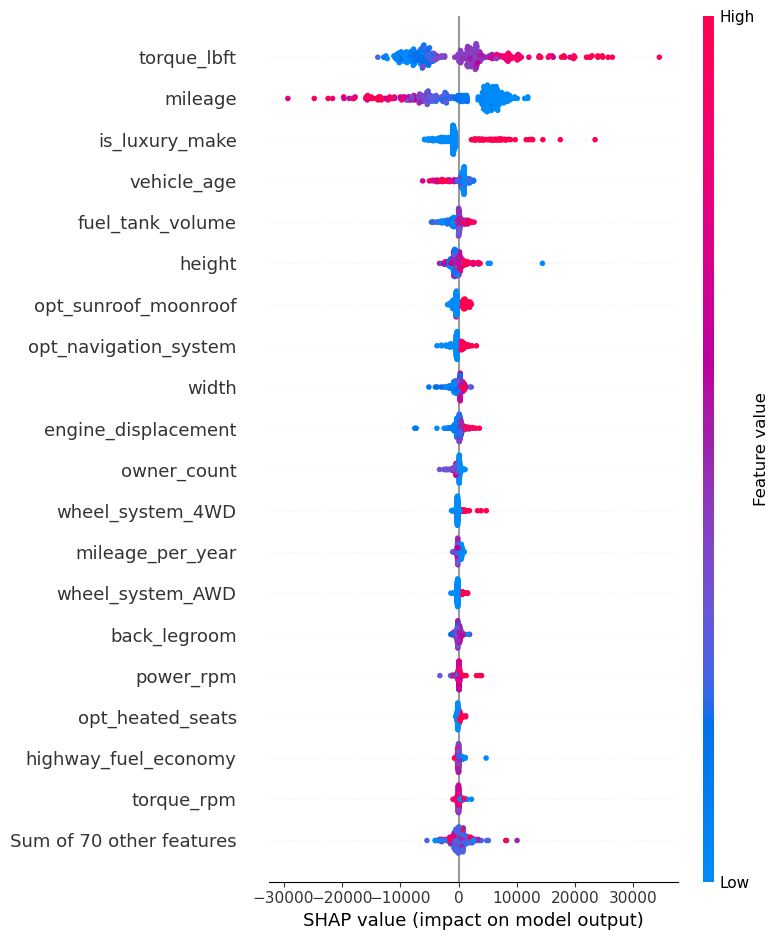

In [8]:
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.tight_layout()
plt.show()

**Interpretation:** The top of the ranking is dominated by powertrain and
size specs, matching what the EDA and Notebook 3 discussion already identified as
price-correlated: `torque_lbft` is the single largest driver by a clear margin, with
high torque (pink) pushing predictions up by as much as ~$30K and low torque (blue)
pulling them down by a similar amount. `mileage` is second, in the expected
direction -- high mileage (pink) pushes price down, low mileage (blue) pushes it up.

`is_luxury_make` ranks third, ahead of `vehicle_age`, `fuel_tank_volume`, and every
raw dimension feature -- a single engineered binary flag is contributing more to
predictions than several continuous size specs. When true (pink), it adds roughly
$10K-25K; when false (blue), its effect clusters tightly near zero. That's a fairly
blunt instrument for something with this much influence, which turns out to matter
for the force-plot cases below.

Below the top three, the ranking is a fairly intuitive mix: physical size
(`fuel_tank_volume`, `height`, `width`, `engine_displacement`), option flags
(`opt_sunroof_moonroof`, `opt_navigation_system`, `opt_heated_seats` -- all pushing
price up when present, as expected), and drivetrain (`wheel_system_4WD`/`AWD`
pushing up when true). `owner_count` has a small but sensible negative effect (pink =
more owners = lower price). Nothing in the top 20 contradicts domain intuition --
every directional effect (more torque, less mileage, luxury brand, more options,
bigger tank/engine → higher price) is the sign we'd expect.

### Force plots

**Selecting predictions to explain.** Rather than picking examples arbitrarily, we
rank every row in the SHAP sample by prediction error and take the two smallest
(closest to right) and two largest (biggest miss) -- this way the four force plots
below aren't cherry-picked, they're just whatever the ranked errors produced.

In [9]:
shap_preds = rf_model.predict(X_shap_sample)
shap_actuals = y_test.loc[X_shap_sample.index]
abs_error = (shap_preds - shap_actuals).abs()

best_2_idx = abs_error.nsmallest(2).index
worst_2_idx = abs_error.nlargest(2).index

print("Closest predictions (smallest absolute error):")
print(pd.DataFrame({'actual': shap_actuals.loc[best_2_idx], 'predicted': shap_preds[abs_error.index.get_indexer(best_2_idx)],
                     'abs_error': abs_error.loc[best_2_idx]}).to_string())
print()
print("Worst predictions (largest absolute error):")
print(pd.DataFrame({'actual': shap_actuals.loc[worst_2_idx], 'predicted': shap_preds[abs_error.index.get_indexer(worst_2_idx)],
                     'abs_error': abs_error.loc[worst_2_idx]}).to_string())

Closest predictions (smallest absolute error):
        actual  predicted  abs_error
47863  17945.0    17945.0        0.0
57752  13419.0    13419.0        0.0

Worst predictions (largest absolute error):
        actual     predicted     abs_error
55910  88595.0  71412.611867  17182.388133
12248  40991.0  29522.012667  11468.987333


**Static force plots** (`matplotlib=True`) rather than the interactive JS
version -- keeps the committed notebook's outputs small and reliably renderable,
per the assignment's "no bloated outputs" requirement, instead of embedding SHAP's
JS/HTML bundle four separate times.

--- Close prediction #1 (row index 47863) ---


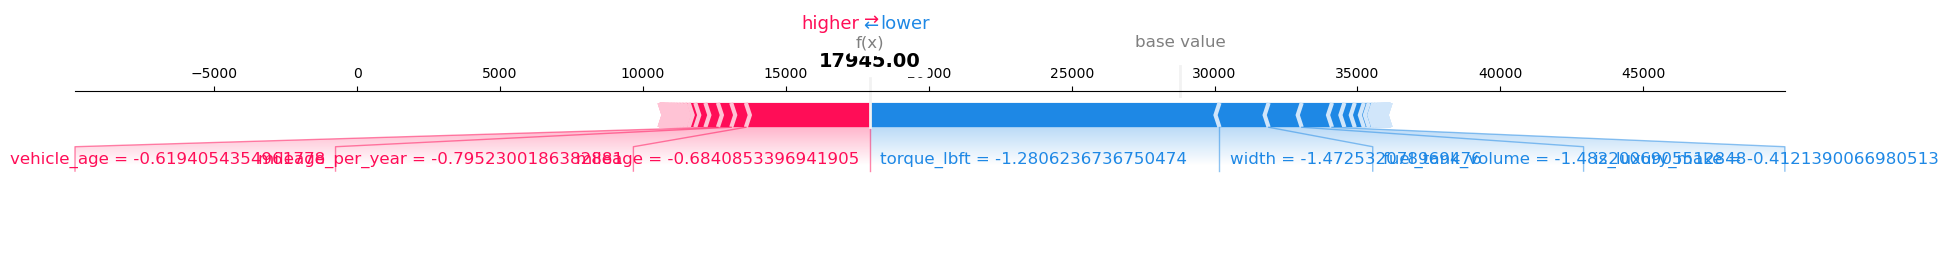

--- Close prediction #2 (row index 57752) ---


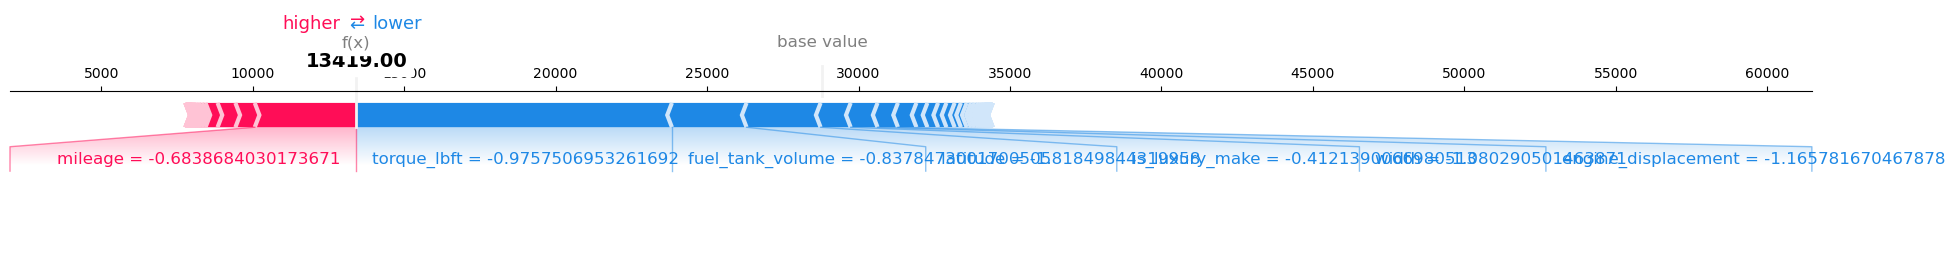

In [10]:
for label, idx in [('Close prediction #1', best_2_idx[0]), ('Close prediction #2', best_2_idx[1])]:
    row_pos = X_shap_sample.index.get_loc(idx)
    print(f"--- {label} (row index {idx}) ---")
    shap.plots.force(shap_values[row_pos], matplotlib=True, show=False)
    plt.tight_layout()
    plt.show()

--- Large-error prediction #1 (row index 55910) ---


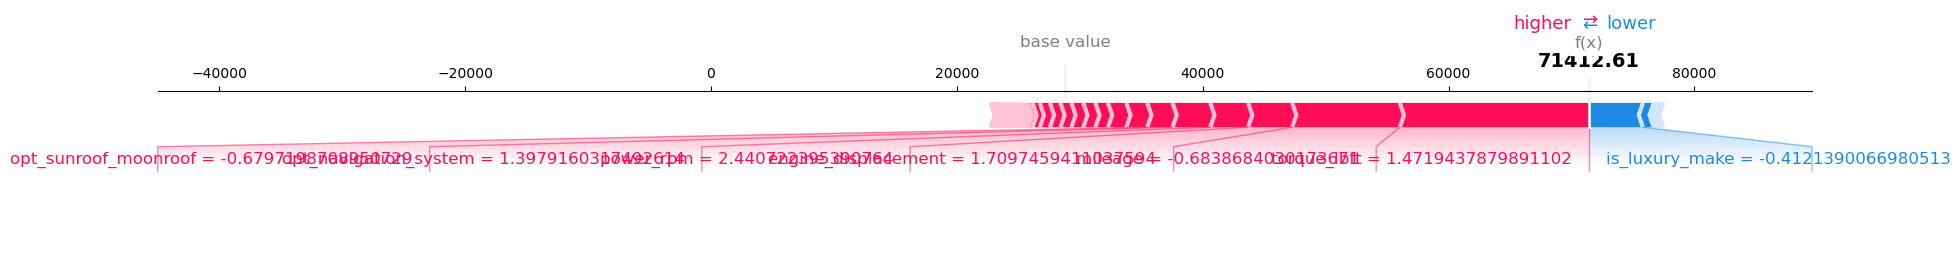

--- Large-error prediction #2 (row index 12248) ---


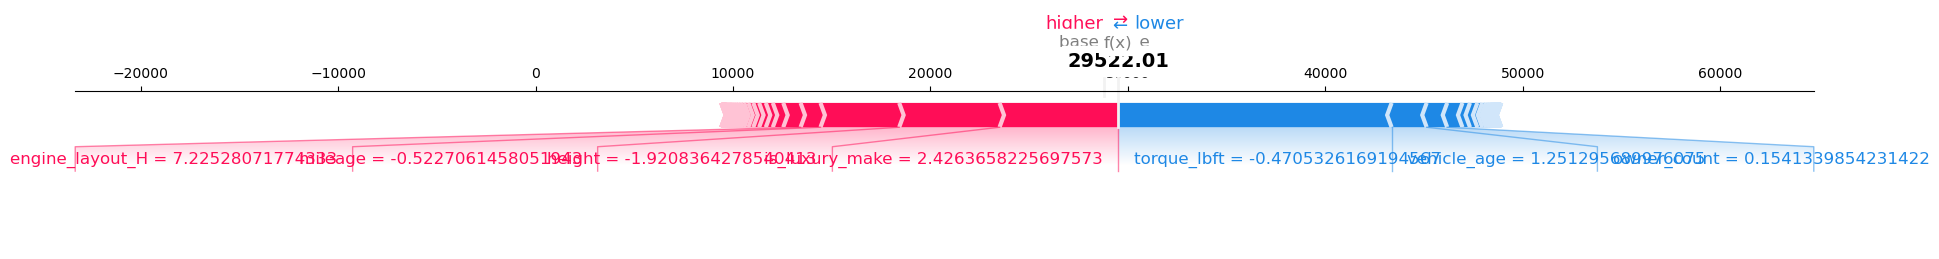

In [11]:
for label, idx in [('Large-error prediction #1', worst_2_idx[0]), ('Large-error prediction #2', worst_2_idx[1])]:
    row_pos = X_shap_sample.index.get_loc(idx)
    print(f"--- {label} (row index {idx}) ---")
    shap.plots.force(shap_values[row_pos], matplotlib=True, show=False)
    plt.tight_layout()
    plt.show()

**Interpretation:**

**The two close predictions (both off by $0.00) are both straightforward,
"boring" cases** -- everything about them is close to average. Row 47863
($17,945): `torque_lbft`, `width`, and `fuel_tank_volume` are all pulling the
prediction *down* from the base value, with only a small `vehicle_age` /
`mileage_per_year` push in the other direction -- a modest, slightly-below-average
car with nothing unusual about it, and the model has plenty of similar training
examples to nail it exactly. Row 57752 ($13,419) is the same story: `torque_lbft`
and `fuel_tank_volume` pulling down, nothing pushing hard in the other direction.
Both are solidly inside the dense part of the price distribution the EDA notebook
identified, which is exactly where a well-trained model should be most confident.

**Both large-error cases are underpredictions, and both involve `is_luxury_make`
as a complicating factor -- in opposite directions.** Row 55910 (actual $88,595,
predicted $71,412, off by $17,182): almost every visible feature is already pushing
the prediction *up* as far as it can go (`power_rpm`, `engine_displacement`,
`opt_navigation_system`, `opt_sunroof_moonroof` all contributing positively), but
`is_luxury_make` is pushing it *down* -- meaning this is a non-"luxury-make" vehicle
that still sold for nearly $90K. Even with every other signal maxed out, the
single binary "is this brand generally luxury" flag drags the prediction back down
by more than the other features can compensate for. Row 12248 (actual $40,991,
predicted $29,522, off by $11,469) is almost the mirror image: `is_luxury_make` is
correctly pushing the price *up* this time, alongside a rare `engine_layout_H`
value (an H/boxer-style engine, uncommon enough in this dataset to carry an
unusually large individual SHAP contribution) and low mileage/height -- but
`vehicle_age` and below-average `torque_lbft` pull it back down, and the net result
still undershoots by over $11K.

**What this points to:** both misses share `is_luxury_make` as a factor, and it's
the same root cause as its outsized rank in the beeswarm plot above -- a single
brand-level binary flag is a coarse proxy for "how much of a price premium does
this specific vehicle actually command." It can't distinguish a top trim of a
mainstream brand from a base trim of a luxury one, or capture rare option
combinations and unusual configurations (like `engine_layout_H`) that carry their
own premium. That's a real, specific gap: the feature-selection process (importance
+ VIF filtering in Notebook 4) kept one blunt luxury flag but dropped or never had a
finer-grained make/trim-level price signal, and these two outliers are exactly the
kind of case that gap costs the most on.

## 3. Bias / Fairness Audit

**Choosing subgroup dimensions.** We audit three of the `meta_`-prefixed columns
retained from Notebook 2: `meta_fuel_type`, `meta_body_type`, and
`meta_transmission`. These were deliberately chosen over something like
`meta_make_name` for this audit -- the EDA notebook found `make_name` has 74 distinct
values, which would produce a cluttered, hard-to-read subgroup breakdown; these three
are low-cardinality (7, 9, and 4 categories respectively, per the EDA notebook's
cardinality analysis) while still being practically meaningful groupings to check for
disparate model performance across.

In [12]:
AUDIT_COLUMNS = ['meta_fuel_type', 'meta_body_type', 'meta_transmission']

missing = [c for c in AUDIT_COLUMNS if c not in test_df.columns]
if missing:
    raise KeyError(f"Expected metadata column(s) not found: {missing}. Available: {metadata_cols}")

y_pred_full = rf_model.predict(X_test)

fairness_metrics = {
    'MAE': mean_absolute_error,
    'MAPE': mean_absolute_percentage_error,
    'R2': r2_score,
}

**Computing subgroup metrics with `MetricFrame`.** One `MetricFrame` per audit
column, each computing the same three regression metrics used throughout this
project (MAE, MAPE, R²) -- both overall and broken out `.by_group`.

In [13]:
metric_frames = {}

for col in AUDIT_COLUMNS:
    mf = MetricFrame(
        metrics=fairness_metrics,
        y_true=y_test,
        y_pred=y_pred_full,
        sensitive_features=test_df[col],
    )
    metric_frames[col] = mf

    print(f"=== {col} ===")
    print(f"Overall: {mf.overall.to_dict()}")
    print(f"By group:")
    print(mf.by_group.to_string())
    print(f"Max disparity (difference): {mf.difference().to_dict()}")
    print(f"Min/max ratio: {mf.ratio().to_dict()}")
    print()

=== meta_fuel_type ===
Overall: {'MAE': 1526.7340929565273, 'MAPE': 0.06775657046512723, 'R2': 0.9723249733419542}
By group:
                           MAE      MAPE        R2
meta_fuel_type                                    
Biodiesel          3636.012432  0.074586  0.896364
Diesel             2432.166555  0.087477  0.963256
Electric           2034.888879  0.068535  0.977192
Flex Fuel Vehicle  1822.888228  0.097060  0.953641
Gasoline           1445.174975  0.065277  0.974562
Hybrid             1099.014659  0.056004  0.976246
Max disparity (difference): {'MAE': 2536.9977731086574, 'MAPE': 0.04105573053932912, 'R2': 0.0808286989611855}
Min/max ratio: {'MAE': 0.3022582237508708, 'MAPE': 0.5770060609663198, 'R2': 0.917284758870306}

=== meta_body_type ===
Overall: {'MAE': 1526.7340929565273, 'MAPE': 0.06775657046512723, 'R2': 0.9723249733419542}
By group:
                         MAE      MAPE        R2
meta_body_type                                  
Convertible      3091.180727  0.1139

### Visualizing disparity across subgroups

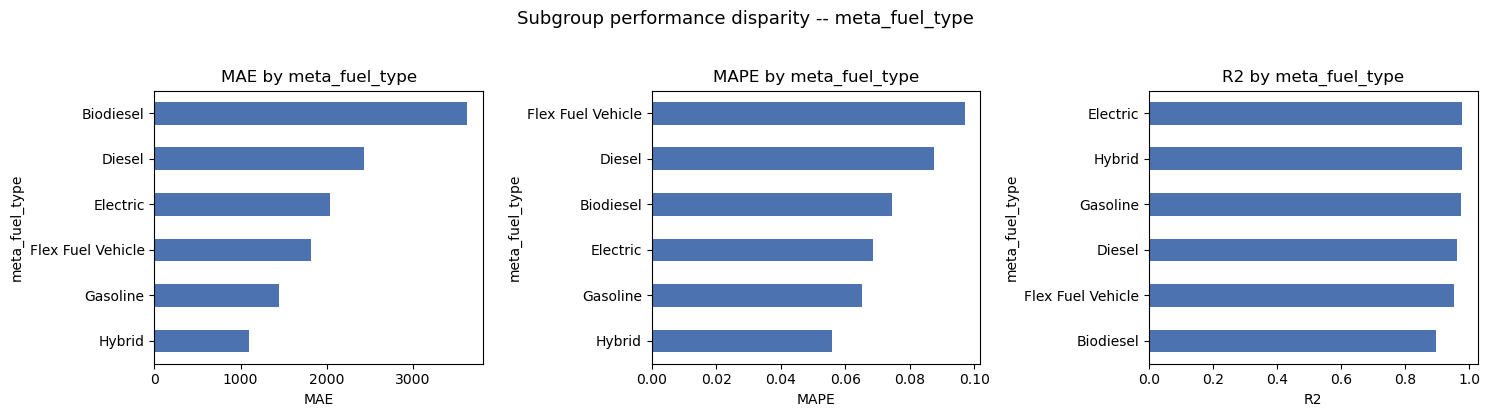

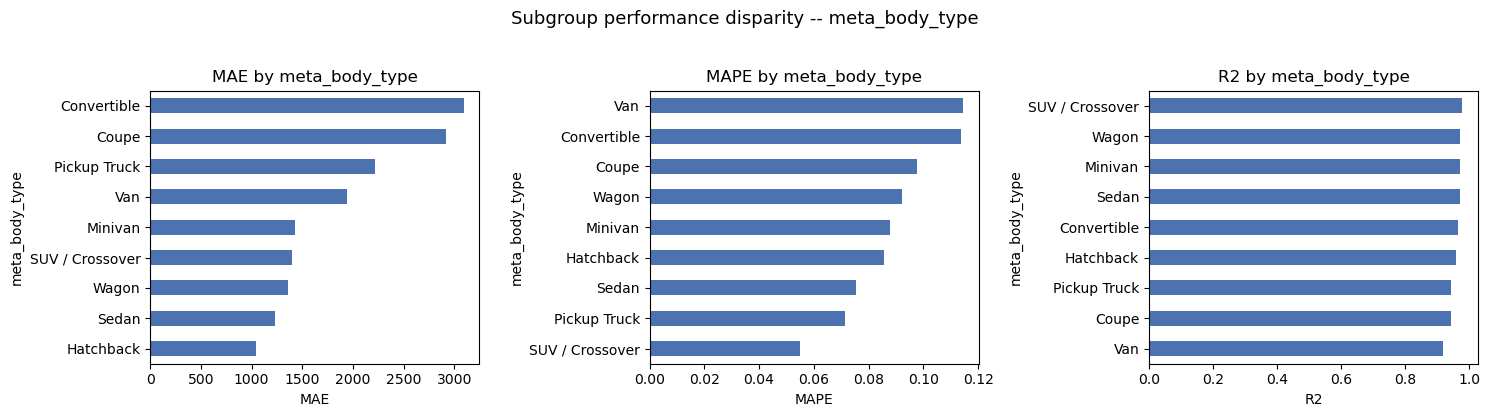

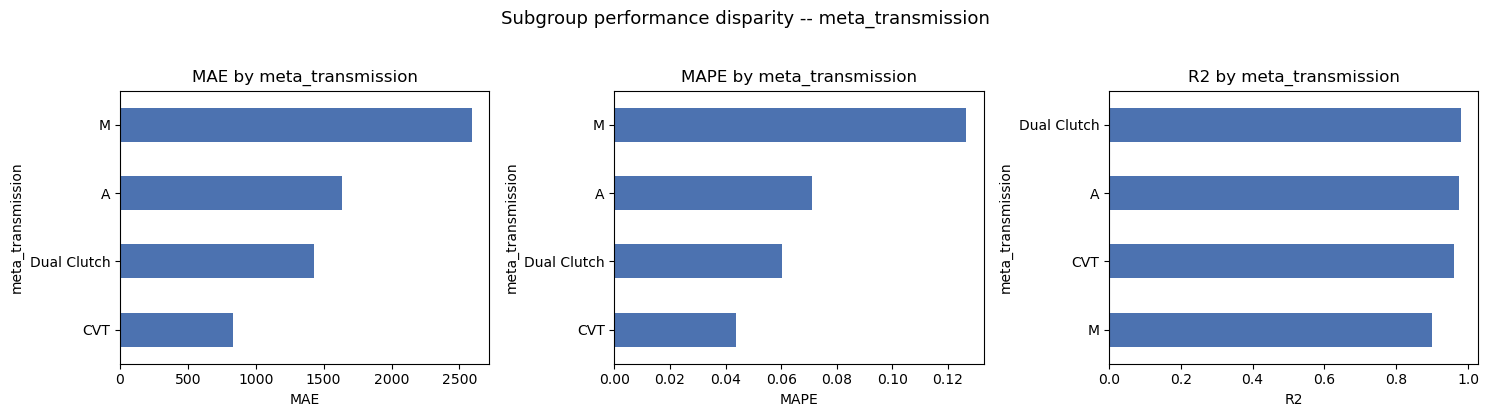

In [14]:
for col in AUDIT_COLUMNS:
    by_group = metric_frames[col].by_group

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, metric_name in zip(axes, ['MAE', 'MAPE', 'R2']):
        by_group[metric_name].sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
        ax.set_title(f'{metric_name} by {col}')
        ax.set_xlabel(metric_name)

    fig.suptitle(f'Subgroup performance disparity -- {col}', y=1.03, fontsize=13)
    plt.tight_layout()
    plt.show()

**Discussion:**

**`meta_fuel_type` -- worst: Biodiesel (MAE \$3,636, R² 0.896); best: Hybrid
(MAE \$1,099, R² 0.976).** The gap is large -- Biodiesel's MAE is over 3x
Hybrid's, and its R² is a full 8 points lower than the best group. Per the EDA
notebook, Gasoline accounts for roughly 87% of all listings, leaving Biodiesel,
Electric, and Flex Fuel Vehicle as small minority categories. That pattern --
worse performance concentrated in the categories we already know are rare -- points
to this being **primarily a data problem**: the model simply saw far fewer Biodiesel
examples to learn an accurate pricing pattern for, not a sign the model or features
are unsuited to that fuel type. Confirming subgroup sizes directly (`test_df[col].value_counts()`)
would make this conclusive, but the concentration of error in exactly the fuel
types the EDA already flagged as thin is strong circumstantial evidence on its own.

**`meta_body_type` -- worst: Van (R² 0.919), Coupe (MAE \$2,916); best: SUV/Crossover
(MAE \$1,402, R² 0.978).** SUV/Crossover is both the best-performing group *and*
the largest body-type segment (~46% of listings per the EDA notebook) -- consistent
with the same data-volume explanation as fuel type. But Convertible and Coupe (MAE
\$3,091 and \$2,916, both far above the \$1,526 overall average) aren't just
small groups -- the EDA notebook's price-by-body-type analysis already showed these
segments have the highest median prices *and* the widest spread, driven by
factors like rarity, collector value, and trim-specific premiums that aren't fully
captured by the remaining specs. That combination -- thin data *and* a segment that's
inherently harder to price precisely -- means this disparity looks like **both a
data problem and an inherent property of the feature-target relationship**, not
purely one or the other.

**`meta_transmission` -- worst: Manual (MAE \$2,591, R² 0.900); best: CVT (MAE \$834,
R² 0.960).** Manual transmission is a well-known minority segment in the current
US used-car market (consistent with the EDA notebook's finding that Automatic
dominates), which again supports a data-volume explanation. But manual-transmission
listings in a mostly-automatic market also skew toward a specific niche --
performance and enthusiast vehicles -- which tend to have wider, less
specification-driven pricing than an ordinary automatic sedan. Same as body type,
this reads as **data scarcity compounding an inherently harder-to-price segment**,
rather than a fixable modeling flaw specific to manual transmissions.

**Overall:** none of the three audited disparities look like a straightforward
*model* problem (e.g. one group's predictions being systematically biased in a way
unrelated to how much data existed for it) -- the pattern is consistent across all
three columns: whichever subgroup has the most listings performs best, and rare
categories that are also inherently higher-variance (collector-adjacent body types,
niche transmissions, uncommon fuel types) perform worst. The most actionable fix
isn't a different model or more feature engineering -- it's more training data for
the underrepresented categories, if that's available; short of that, this is a
disparity worth disclosing rather than one the current pipeline can fully correct.